In [1]:

import io
import pandas as pd
import numpy as np



In [2]:
# 1. CARGA DE DATOS
# Puedes descomentar la siguiente línea para leer tu archivo real:

df = pd.read_csv('full_matches_data.csv')

print("--- INFORMACIÓN GENERAL DEL DATASET ---")
print(df.info())
print("\n")

# 2. VALIDACIÓN DE COMPLETUD (10 jugadores x 15 minutos)
print("--- VALIDACIÓN DE COMPLETUD POR PARTIDA ---")
match_counts = df.groupby('matchId').agg(
    unique_players=('participantId', 'nunique'),
    min_minute=('minute', 'min'),
    max_minute=('minute', 'max'),
    total_records=('participantId', 'count')
).reset_index()

invalid_matches = match_counts[
    (match_counts['unique_players'] != 10) |
    (match_counts['min_minute'] != 0) |
    (match_counts['max_minute'] != 14) |
    (match_counts['total_records'] != 150)
]

if invalid_matches.empty:
    print("✅ Todas las partidas tienen la estructura espacio-temporal correcta (10 jugadores, 15 snapshots y minuto 0-14).")
else:
    print(f"⚠️ Se detectaron {len(invalid_matches)} partidas con estructura corrupta:")
    print(invalid_matches.head())

player_minute_stats = df.groupby(['matchId', 'participantId']).agg(
    unique_minutes=('minute', 'nunique'),
    min_minute=('minute', 'min'),
    max_minute=('minute', 'max')
).reset_index()

player_issues = player_minute_stats[
    (player_minute_stats['unique_minutes'] != 15) |
    (player_minute_stats['min_minute'] != 0) |
    (player_minute_stats['max_minute'] != 14)
]

if player_issues.empty:
    print("✅ Cada jugador tiene los 15 minutos únicos entre 0 y 14.")
else:
    print(f"⚠️ Hay {player_issues['matchId'].nunique()} partidas con jugadores que no tienen 15 minutos completos.")
    print(player_issues.head())

# 3. DETECCIÓN DE AFKs (Varianza cero en XP)
print("\n--- DETECCIÓN DE POSIBLES AFKs/DESCONEXIONES ---")
# Calculamos el incremento de XP por minuto para cada jugador
df = df.sort_values(by=['matchId', 'participantId', 'minute'])
df['xp_diff'] = df.groupby(['matchId', 'participantId'])['xp'].diff().fillna(0)

# Si un jugador tiene un incremento de XP de 0 durante más de 3 minutos consecutivos después del min 2, es sospechoso
afk_candidates = df[(df['minute'] > 2) & (df['xp_diff'] == 0)].groupby(
    ['matchId', 'participantId', 'championName']
).size().reset_index(name='consecutive_zero_xp_mins')

afk_critical = afk_candidates[afk_candidates['consecutive_zero_xp_mins'] >= 3]

if afk_critical.empty:
    print("✅ No se detectaron jugadores inactivos (AFK) críticos en el early game.")
else:
    print(f"⚠️ Se detectaron {len(afk_critical)} posibles AFKs (0 XP ganada por >= 3 mins):")
    print(afk_critical)

# 4. REVISIÓN DE NULOS
print("--- REVISIÓN DE VALORES NULOS ---")
null_counts = df.isnull().sum()
null_cols = null_counts[null_counts > 0]
if null_cols.empty:
    print("✅ No hay valores nulos en el dataset.")
else:
    print("⚠️ Columnas con valores nulos:")
    print(null_cols)


--- INFORMACIÓN GENERAL DEL DATASET ---
<class 'pandas.DataFrame'>
RangeIndex: 2094495 entries, 0 to 2094494
Data columns (total 28 columns):
 #   Column               Dtype  
---  ------               -----  
 0   timestamp            int64  
 1   minute               int64  
 2   participantId        int64  
 3   currentGold          int64  
 4   totalGold            int64  
 5   level                int64  
 6   xp                   int64  
 7   minionsKilled        int64  
 8   jungleMinionsKilled  int64  
 9   position_x           int64  
 10  position_y           int64  
 11  championName         str    
 12  teamPosition         str    
 13  matchId              str    
 14  gameDuration         int64  
 15  win                  bool   
 16  teamId               int64  
 17  teamName             str    
 18  firstBlood           float64
 19  firstBloodAssist     float64
 20  firstBloodKill       float64
 21  firstDragon          float64
 22  firstTower           float64
 23  fir

--- GRÁFICOS INICIALES (Dataset completo) ---
Conteo de resultados por equipo en el dataset completo:
win
False    14166
True     14145
Proporción de victorias: 0.000


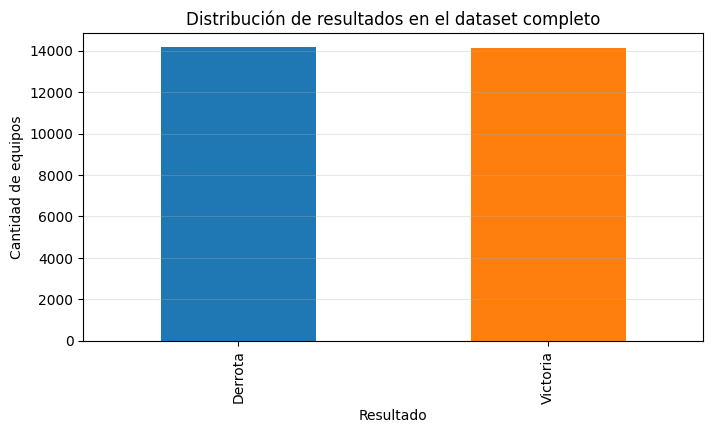

<Figure size 800x400 with 0 Axes>

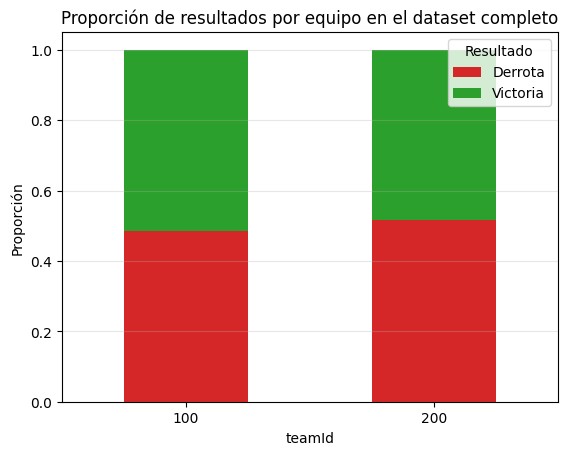

Resumen de balance por equipo:
win     False  True 
teamId              
100     0.485  0.515
200     0.516  0.484


In [3]:
# GRÁFICOS INICIALES EN EL DATASET COMPLETO
import matplotlib.pyplot as plt

print('--- GRÁFICOS INICIALES (Dataset completo) ---')

match_team_win = df.groupby(['matchId', 'teamId'], as_index=False).agg(win=('win', 'max'))
win_counts = match_team_win['win'].value_counts().sort_index()

print('Conteo de resultados por equipo en el dataset completo:')
print(win_counts.to_string())
print(f'Proporción de victorias: {win_counts.get(1, 0) / win_counts.sum():.3f}')

plt.figure(figsize=(8, 4))
win_counts.plot(kind='bar', color=['#1f77b4', '#ff7f0e'])
plt.title('Distribución de resultados en el dataset completo')
plt.xticks([0, 1], ['Derrota', 'Victoria'])
plt.ylabel('Cantidad de equipos')
plt.xlabel('Resultado')
plt.grid(axis='y', alpha=0.3)
plt.show()

team_win = match_team_win.groupby('teamId')['win'].value_counts(normalize=True).unstack(fill_value=0)

plt.figure(figsize=(8, 4))
team_win.plot(kind='bar', stacked=True, color=['#d62728', '#2ca02c'])
plt.title('Proporción de resultados por equipo en el dataset completo')
plt.ylabel('Proporción')
plt.xlabel('teamId')
plt.legend(['Derrota', 'Victoria'], title='Resultado', loc='upper right')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

print('Resumen de balance por equipo:')
print(team_win.round(3))

In [4]:
# Asumimos que 'df' sigue en memoria desde la celda anterior.
print(f"--- ESTADO INICIAL ---")
print(f"Dimensiones previas: {df.shape}")
print(f"Partidas totales previas: {df['matchId'].nunique()}")

# ---------------------------------------------------------
# REGLA 1: ELIMINAR PARTIDAS CON ESTRUCTURA CORRUPTA
# ---------------------------------------------------------
# Verificamos que tenga 10 jugadores, que sean estrictamente del ID 1 al 10, y con 150 registros.
match_counts = df.groupby('matchId').agg(
    unique_players=('participantId', 'nunique'),
    total_records=('participantId', 'count'),
    max_participant_id=('participantId', 'max'),
    min_participant_id=('participantId', 'min')
).reset_index()

player_minutes = df.groupby(['matchId', 'participantId']).agg(
    unique_minutes=('minute', 'nunique'),
    min_minute=('minute', 'min'),
    max_minute=('minute', 'max')
).reset_index()

player_issue_matches = player_minutes[
    (player_minutes['unique_minutes'] != 15) |
    (player_minutes['min_minute'] != 0) |
    (player_minutes['max_minute'] != 14)
]['matchId'].unique()

valid_matches = match_counts[
    (match_counts['unique_players'] == 10) &
    (match_counts['total_records'] == 150) &
    (match_counts['max_participant_id'] == 10) &
    (match_counts['min_participant_id'] == 1) &
    (~match_counts['matchId'].isin(player_issue_matches))
]['matchId']

# Filtramos conservando solo los válidos
df_clean = df[df['matchId'].isin(valid_matches)].copy()
print(f"Partidas retenidas tras limpieza estructural: {df_clean['matchId'].nunique()}")

# ---------------------------------------------------------
# REGLA 2: ELIMINAR PARTIDAS CON AFKs (4v5)
# ---------------------------------------------------------
# Nos aseguramos del orden lógico temporal
df_clean = df_clean.sort_values(by=['matchId', 'participantId', 'minute'])

# Incremento de XP por minuto
df_clean['xp_diff'] = df_clean.groupby(['matchId', 'participantId'])['xp'].diff().fillna(0)

# Jugadores con 0 XP por >= 3 mins después del min 2
afk_mask = (df_clean['minute'] > 2) & (df_clean['xp_diff'] == 0)
afk_candidates = df_clean[afk_mask].groupby(['matchId', 'participantId']).size().reset_index(name='consecutive_zero_xp_mins')
afk_critical = afk_candidates[afk_candidates['consecutive_zero_xp_mins'] >= 3]

# Identificamos el matchId de los AFKs y eliminamos la partida COMPLETA
afk_matches = afk_critical['matchId'].unique()
df_clean = df_clean[~df_clean['matchId'].isin(afk_matches)].copy()
print(f"Partidas retenidas tras eliminar juegos con AFKs: {df_clean['matchId'].nunique()}")

# ---------------------------------------------------------
# REGLA 2B: ELIMINAR PARTIDAS CON DURACIÓN MENOR A 15 MINUTOS
# ---------------------------------------------------------
duration_by_match = df_clean.groupby('matchId')['gameDuration'].first().reset_index()
short_duration_matches = duration_by_match[duration_by_match['gameDuration'] < 15 * 60]['matchId']
if len(short_duration_matches) > 0:
    print(f"⚠️ Eliminando {len(short_duration_matches)} partidas con duración < 15 minutos.")
    df_clean = df_clean[~df_clean['matchId'].isin(short_duration_matches)].copy()

# ---------------------------------------------------------
# REGLA 2C: ELIMINAR PARTIDAS CON ACCIÓN TEMPRANA AUSENTE
# ---------------------------------------------------------
early_action = df_clean[df_clean['minute'] <= 10].groupby('matchId').agg(
    total_kills=('kills', 'sum'),
    max_firstDragon=('firstDragon', 'max'),
    max_firstTower=('firstTower', 'max')
).reset_index()

no_action_matches = early_action[
    (early_action['total_kills'] == 0) &
    (early_action['max_firstDragon'] == 0) &
    (early_action['max_firstTower'] == 0)
]['matchId']

if len(no_action_matches) > 0:
    print(f"⚠️ Eliminando {len(no_action_matches)} partidas sin acción temprana hasta el minuto 10.")
    df_clean = df_clean[~df_clean['matchId'].isin(no_action_matches)].copy()

# Limpiamos columna auxiliar
df_clean = df_clean.drop(columns=['xp_diff'])
print(f"Partidas retenidas tras eliminar juegos con AFKs y partidas no válidas: {df_clean['matchId'].nunique()}")

# ---------------------------------------------------------
# REGLA 3: ELIMINAR COLUMNA 'firstBlood'
# ---------------------------------------------------------
if 'firstBlood' in df_clean.columns:
    df_clean.drop(columns=['firstBlood'], inplace=True)
    print("Columna 'firstBlood' eliminada.")

# ---------------------------------------------------------
# REGLA 4: RELLENO DE NULOS EN EVENTOS Y OBJETIVOS
# ---------------------------------------------------------
event_columns = [
    'firstBloodAssist', 'firstBloodKill', 'firstDragon',
    'firstTower', 'firstTowerAssist', 'firstTowerKill'
]

for col in event_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

# ---------------------------------------------------------
print("\n--- ESTADO DESPUÉS DE LA LIMPIEZA ---")
print(f"Dimensiones finales: {df_clean.shape}")

nulos_restantes = df_clean.isnull().sum()
nulos_restantes = nulos_restantes[nulos_restantes > 0]

if not nulos_restantes.empty:
    print("\n⚠️ Nulos restantes por columna (Esperado solo teamPosition):")
    print(nulos_restantes)
else:
    print("\n✅ Dataset 100% libre de nulos.")


--- ESTADO INICIAL ---
Dimensiones previas: (2094495, 29)
Partidas totales previas: 14171
Partidas retenidas tras limpieza estructural: 12645
Partidas retenidas tras eliminar juegos con AFKs: 12145
Partidas retenidas tras eliminar juegos con AFKs y partidas no válidas: 12145
Columna 'firstBlood' eliminada.

--- ESTADO DESPUÉS DE LA LIMPIEZA ---
Dimensiones finales: (1821750, 27)

⚠️ Nulos restantes por columna (Esperado solo teamPosition):
teamPosition    168150
dtype: int64


--- GRÁFICOS DESPUÉS DEL EDA (Dataset limpio) ---
Conteo de resultados por equipo en el dataset limpio:
win
False    12145
True     12145
Proporción de victorias: 0.000


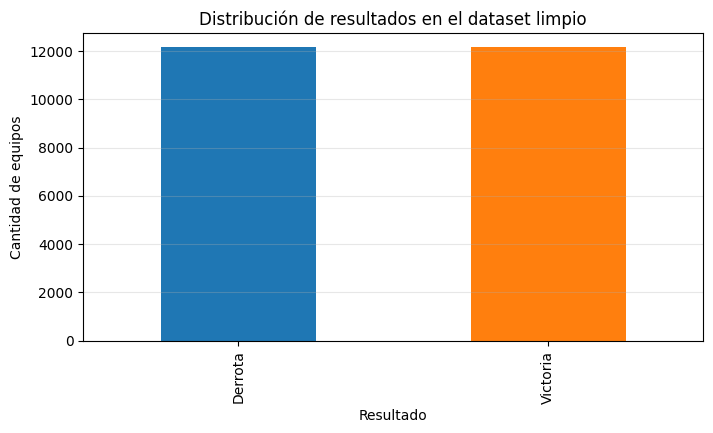

Partidas sin acción temprana hasta el minuto 10 en el dataset limpio: 0


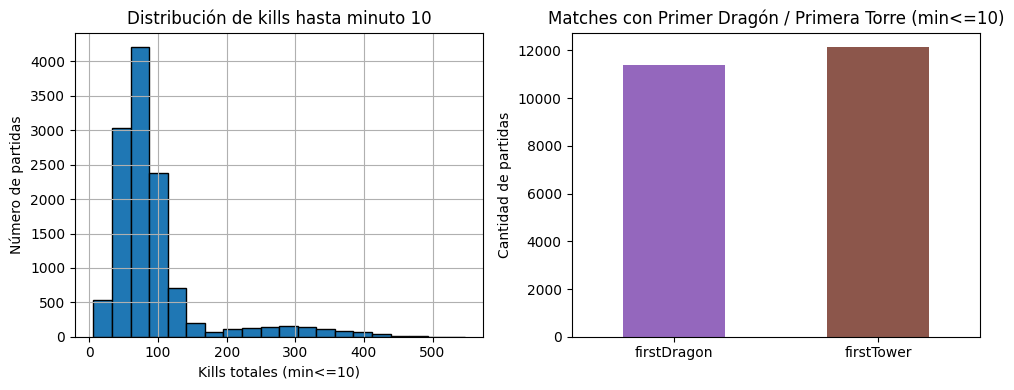

Distribución de kills tempranas (min<=10):
count    12145.00
mean        94.26
std         70.75
min          6.00
25%         57.00
50%         76.00
75%         99.00
max        547.00
Name: total_kills, dtype: float64


In [5]:
# GRÁFICOS DESPUÉS DEL EDA (Dataset limpio)
import matplotlib.pyplot as plt

print('--- GRÁFICOS DESPUÉS DEL EDA (Dataset limpio) ---')

match_team_win_clean = df_clean.groupby(['matchId', 'teamId'], as_index=False).agg(win=('win', 'max'))
win_counts_clean = match_team_win_clean['win'].value_counts().sort_index()

print('Conteo de resultados por equipo en el dataset limpio:')
print(win_counts_clean.to_string())
print(f'Proporción de victorias: {win_counts_clean.get(1, 0) / win_counts_clean.sum():.3f}')

plt.figure(figsize=(8, 4))
win_counts_clean.plot(kind='bar', color=['#1f77b4', '#ff7f0e'])
plt.title('Distribución de resultados en el dataset limpio')
plt.xticks([0, 1], ['Derrota', 'Victoria'])
plt.ylabel('Cantidad de equipos')
plt.xlabel('Resultado')
plt.grid(axis='y', alpha=0.3)
plt.show()

early_action_clean = df_clean[df_clean['minute'] <= 10].groupby('matchId').agg(            total_kills=('kills', 'sum'),             firstDragon=('firstDragon', 'max'),             firstTower=('firstTower', 'max')        ).reset_index()

zero_action = early_action_clean[(early_action_clean['total_kills'] == 0) & (early_action_clean['firstDragon'] == 0) & (early_action_clean['firstTower'] == 0)]
print(f'Partidas sin acción temprana hasta el minuto 10 en el dataset limpio: {len(zero_action)}')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
early_action_clean['total_kills'].hist(bins=20, color='#1f77b4', edgecolor='black')
plt.title('Distribución de kills hasta minuto 10')
plt.xlabel('Kills totales (min<=10)')
plt.ylabel('Número de partidas')

plt.subplot(1, 2, 2)
early_action_clean[['firstDragon', 'firstTower']].sum().plot(kind='bar', color=['#9467bd', '#8c564b'])
plt.title('Matches con Primer Dragón / Primera Torre (min<=10)')
plt.ylabel('Cantidad de partidas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('Distribución de kills tempranas (min<=10):')
print(early_action_clean['total_kills'].describe().round(2))

In [6]:
print("--- INICIANDO AGREGACIÓN A NIVEL DE EQUIPO ---")

# 1. Definir cómo vamos a agregar las métricas de los 5 jugadores
agregaciones = {
    'totalGold': 'sum',
    'xp': 'sum',
    'minionsKilled': 'sum',
    'jungleMinionsKilled': 'sum',
    'kills': 'sum',
    'deaths': 'sum',
    'assists': 'sum',
    # Para los eventos, usamos 'max'. Si un jugador tiene 1 (lo logró), todo el equipo tiene 1.
    'firstBloodKill': 'max',
    'firstDragon': 'max',
    'firstTowerKill': 'max',
    'win': 'max' # La victoria es igual para los 5 miembros
}

# 2. Agrupar por Partida, Minuto y Equipo
df_team = df_clean.groupby(['matchId', 'minute', 'teamId']).agg(agregaciones).reset_index()

# 3. Separar Equipo Azul (100) y Equipo Rojo (200)
# Usamos set_index para alinear las filas perfectamente por partida y minuto
blue_team = df_team[df_team['teamId'] == 100].set_index(['matchId', 'minute'])
red_team = df_team[df_team['teamId'] == 200].set_index(['matchId', 'minute'])

# 4. Calcular Diferenciales (Equipo Azul - Equipo Rojo)
# Las métricas que importan para ganar son las relativas, no las absolutas.
diff_cols = ['totalGold', 'xp', 'minionsKilled', 'jungleMinionsKilled', 'kills']
blue_diff = blue_team[diff_cols].sub(red_team[diff_cols])

# Renombrar columnas para claridad
blue_diff.columns = [f"{col}_diff" for col in diff_cols]

# 5. Construir el Dataset Final de Modelado (Perspectiva Equipo Azul)
df_model = pd.DataFrame({
    # Target
    'blue_win': blue_team['win'].astype(int),

    # Diferenciales (Azul - Rojo)
    'gold_diff': blue_diff['totalGold_diff'],
    'xp_diff': blue_diff['xp_diff'],
    'minions_diff': blue_diff['minionsKilled_diff'],
    'jungle_minions_diff': blue_diff['jungleMinionsKilled_diff'],
    'kills_diff': blue_diff['kills_diff'],

    # Métricas Absolutas del Equipo Azul (Contexto)
    'blue_kills': blue_team['kills'],
    'blue_deaths': blue_team['deaths'],
    'blue_assists': blue_team['assists'],

    # Control de Mapa y Objetivos (Acumulativo del Equipo Azul)
    'blue_firstBlood': blue_team['firstBloodKill'].astype(int),
    'blue_firstDragon': blue_team['firstDragon'].astype(int),
    'blue_firstTower': blue_team['firstTowerKill'].astype(int)
}).reset_index()

print("--- ESTADO DEL DATASET DE MODELADO ---")
print(f"Dimensiones del nuevo dataset: {df_model.shape}")
print(f"Filas esperadas: {12189 * 15} (12,189 partidas * 15 minutos)")
print("\nMuestra de las métricas al minuto 14 (Early Game Final):")
print(df_model[df_model['minute'] == 14].head())

# Validar Balance de Clases
win_rate_blue = df_model[df_model['minute'] == 14]['blue_win'].mean() * 100
print(f"\nTasa de Victoria del Equipo Azul (Balance de clases): {win_rate_blue:.2f}%")

--- INICIANDO AGREGACIÓN A NIVEL DE EQUIPO ---
--- ESTADO DEL DATASET DE MODELADO ---
Dimensiones del nuevo dataset: (182175, 14)
Filas esperadas: 182835 (12,189 partidas * 15 minutos)

Muestra de las métricas al minuto 14 (Early Game Final):
           matchId  minute  blue_win  gold_diff  xp_diff  minions_diff  \
14  LA2_1419072843      14         1       3458      413             7   
29  LA2_1419087923      14         1       6129     4781            50   
44  LA2_1419103640      14         1      -2303     1526            11   
59  LA2_1419468874      14         0       -370     -359             9   
74  LA2_1419469852      14         0      -3879    -2500           -23   

    jungle_minions_diff  kills_diff  blue_kills  blue_deaths  blue_assists  \
14                    0           4          16           12            20   
29                   56           8          13            5             8   
44                   -1          -1          14           15            15   


In [7]:
print("--- LIMPIEZA FINAL DE SECUENCIAS ---")
# 1. Eliminar las partidas que quedaron con menos de 15 minutos (las 44 filas faltantes)
min_counts = df_model.groupby('matchId').size()
valid_matches_model = min_counts[min_counts == 15].index
df_model = df_model[df_model['matchId'].isin(valid_matches_model)].copy()
print(f"Partidas finales perfectas retenidas: {df_model['matchId'].nunique()}")
print(f"Filas finales: {df_model.shape[0]} (Exactamente partidas * 15)\n")

# 2. Correlación de features con la victoria al final del early game (Minuto 14)
df_m14 = df_model[df_model['minute'] == 14].copy()

# Excluir variables no numéricas antes de correlacionar
cols_to_correlate = df_m14.select_dtypes(include=[np.number]).columns
correlations_m14 = df_m14[cols_to_correlate].corr()['blue_win'].sort_values(ascending=False)

print("--- CORRELACIÓN CON LA VICTORIA (MINUTO 14) ---")
print("Top variables predictivas:")
print(correlations_m14.drop(['blue_win', 'minute']))

# 3. Evolución temporal del poder predictivo (Correlación por minuto)
print("\n--- EVOLUCIÓN DEL PODER PREDICTIVO (r de Pearson) ---")
temporal_corr = []
for m in range(15):
    df_m = df_model[df_model['minute'] == m]
    corr_gold = df_m['gold_diff'].corr(df_m['blue_win'])
    corr_xp = df_m['xp_diff'].corr(df_m['blue_win'])
    temporal_corr.append({'minute': m, 'gold_corr': corr_gold, 'xp_corr': corr_xp})

df_temporal_corr = pd.DataFrame(temporal_corr)
print(df_temporal_corr.to_string(index=False))

# 4. Análisis de Outliers (Stomps) para Estrategia de Clipping
print("\n--- ANÁLISIS DE OUTLIERS (STOMPS) AL MIN 14 ---")
print("Percentiles de gold_diff (Diferencia de Oro):")
print(df_m14['gold_diff'].quantile([0.01, 0.05, 0.5, 0.95, 0.99]))

print("\nPercentiles de kills_diff (Diferencia de Kills):")
print(df_m14['kills_diff'].quantile([0.01, 0.05, 0.5, 0.95, 0.99]))

--- LIMPIEZA FINAL DE SECUENCIAS ---
Partidas finales perfectas retenidas: 12145
Filas finales: 182175 (Exactamente partidas * 15)

--- CORRELACIÓN CON LA VICTORIA (MINUTO 14) ---
Top variables predictivas:
gold_diff              0.481161
xp_diff                0.434560
kills_diff             0.425574
minions_diff           0.310393
jungle_minions_diff    0.231706
blue_firstDragon       0.205966
blue_kills             0.159757
blue_assists           0.068908
blue_deaths           -0.179397
blue_firstBlood             NaN
blue_firstTower             NaN
Name: blue_win, dtype: float64

--- EVOLUCIÓN DEL PODER PREDICTIVO (r de Pearson) ---
 minute  gold_corr  xp_corr
      0        NaN      NaN
      1   0.032620 0.006729
      2   0.098393 0.094998
      3   0.162793 0.143331
      4   0.217828 0.197044
      5   0.250839 0.217238
      6   0.288196 0.256446
      7   0.313730 0.278683
      8   0.338433 0.301649
      9   0.369305 0.331365
     10   0.386505 0.346141
     11   0.409694 

C:\Users\morei\AppData\Roaming\Python\Python314\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\morei\AppData\Roaming\Python\Python314\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [8]:
print("--- APLICANDO TRANSFORMACIONES FINALES ---")

# 1. Corrección de Eventos (Transformación Acumulativa)
# Hacemos que si un evento ocurre, se mantenga en '1' para el resto de la partida
eventos_acumulativos = ['blue_firstBlood', 'blue_firstDragon', 'blue_firstTower']

df_model = df_model.sort_values(by=['matchId', 'minute'])
for col in eventos_acumulativos:
    df_model[col] = df_model.groupby('matchId')[col].cummax()

print("✅ Variables de eventos transformadas a cumulativas.")

# Validamos rápidamente que se solucionó el problema de varianza cero
var_check = df_model[df_model['minute'] == 14][eventos_acumulativos].var()
print(f"Varianza al min 14 (debe ser > 0):\n{var_check}\n")

# 2. Clipping de Outliers Extremos (Stomps)
# Limitamos los valores al P01 y P99 calculados en el EDA
features_to_clip = ['gold_diff', 'xp_diff', 'minions_diff', 'jungle_minions_diff', 'kills_diff']

for col in features_to_clip:
    lower_bound = df_model[col].quantile(0.01)
    upper_bound = df_model[col].quantile(0.99)
    df_model[col] = df_model[col].clip(lower=lower_bound, upper=upper_bound)

print("✅ Clipping aplicado a diferenciales (Límites P01 y P99).")

# 3. Ordenamiento final e Índices
# Dejamos el dataset ordenado para modelos secuenciales
df_final = df_model.sort_values(by=['matchId', 'minute']).reset_index(drop=True)

# 4. Exportar el Dataset Limpio
output_filename = "league_early_game_ml_ready.csv"
df_final.to_csv(output_filename, index=False)

print("\n--- ¡DATASET FINALIZADO Y EXPORTADO! ---")
print(f"Dimensiones finales: {df_final.shape}")
print(f"Archivo guardado como: '{output_filename}'")

--- APLICANDO TRANSFORMACIONES FINALES ---
✅ Variables de eventos transformadas a cumulativas.
Varianza al min 14 (debe ser > 0):
blue_firstBlood     0.000000
blue_firstDragon    0.247222
blue_firstTower     0.000000
dtype: float64

✅ Clipping aplicado a diferenciales (Límites P01 y P99).

--- ¡DATASET FINALIZADO Y EXPORTADO! ---
Dimensiones finales: (182175, 14)
Archivo guardado como: 'league_early_game_ml_ready.csv'


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

In [10]:
print("--- PURGA FINAL DE VARIABLES CONSTANTES ---")

# Cargamos el dataset que exportamos en el paso anterior
df_final = pd.read_csv("league_early_game_ml_ready.csv")

# Eliminamos variables con varianza cero
cols_to_drop = ['blue_firstBlood', 'blue_firstTower']
df_final = df_final.drop(columns=cols_to_drop, errors='ignore')
print(f"✅ Columnas {cols_to_drop} eliminadas por falta de varianza.")

# ---------------------------------------------------------
# PREPARACIÓN PARA MACHINE LEARNING (ENFOQUE TABULAR MINUTO 14)
# ---------------------------------------------------------
print("\n--- CREANDO DATASET PARA MODELO BASELINE (MINUTO 14) ---")
# Filtramos solo el snapshot más rico en información
df_m14 = df_final[df_final['minute'] == 14].copy()

# Definimos variables predictoras (X) y variable objetivo (y)
# Excluimos 'matchId' y 'minute' porque no son predictoras numéricas válidas
X = df_m14.drop(columns=['matchId', 'minute', 'blue_win'])
y = df_m14['blue_win']

# Hacemos el Train/Test Split (80% entrenamiento, 20% prueba)
# Usamos stratify=y para asegurar que mantengamos el balance de ~50% de victorias en ambos sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Tamaño del set de Entrenamiento (Train): {X_train.shape[0]} partidas")
print(f"Tamaño del set de Prueba (Test): {X_test.shape[0]} partidas")
print("\nVariables (Features) listas para el modelo:")
print(X_train.columns.tolist())

--- PURGA FINAL DE VARIABLES CONSTANTES ---
✅ Columnas ['blue_firstBlood', 'blue_firstTower'] eliminadas por falta de varianza.

--- CREANDO DATASET PARA MODELO BASELINE (MINUTO 14) ---
Tamaño del set de Entrenamiento (Train): 9716 partidas
Tamaño del set de Prueba (Test): 2429 partidas

Variables (Features) listas para el modelo:
['gold_diff', 'xp_diff', 'minions_diff', 'jungle_minions_diff', 'kills_diff', 'blue_kills', 'blue_deaths', 'blue_assists', 'blue_firstDragon']


In [11]:
print("--- INICIANDO ENTRENAMIENTO DE MODELOS ---")

# 1. Instanciar los modelos con parámetros base robustos
modelos = {
    "Regresión Logística": LogisticRegression(max_iter=2000, random_state=42, solver='liblinear'),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='logloss')
}

# 2. Diccionario para guardar los resultados
resultados = []

# 3. Bucle de entrenamiento y evaluación
for nombre, modelo in modelos.items():
    print(f"Entrenando {nombre}...")

    # Entrenar el modelo
    modelo.fit(X_train, y_train)

    # Predecir sobre el set de prueba
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1] # Probabilidad de que gane el Azul

    # Calcular métricas
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    # Guardar resultados
    resultados.append({
        "Modelo": nombre,
        "Accuracy": acc,
        "ROC-AUC": auc
    })

# 4. Mostrar el Benchmark comparativo
print("\n--- RESULTADOS DEL BENCHMARK (MINUTO 14) ---")
df_resultados = pd.DataFrame(resultados).sort_values(by="ROC-AUC", ascending=False)
print(df_resultados.to_string(index=False))

# 5. Reporte detallado del modelo ganador (el primero en el dataframe)
mejor_modelo_nombre = df_resultados.iloc[0]['Modelo']
mejor_modelo_obj = modelos[mejor_modelo_nombre]

print(f"\n--- REPORTE DETALLADO DEL MEJOR MODELO: {mejor_modelo_nombre} ---")
y_pred_mejor = mejor_modelo_obj.predict(X_test)
print(classification_report(y_test, y_pred_mejor, target_names=["Gana Rojo (0)", "Gana Azul (1)"]))

--- INICIANDO ENTRENAMIENTO DE MODELOS ---
Entrenando Regresión Logística...
Entrenando Random Forest...
Entrenando XGBoost...

--- RESULTADOS DEL BENCHMARK (MINUTO 14) ---
             Modelo  Accuracy  ROC-AUC
            XGBoost  0.710992 0.784128
      Random Forest  0.700288 0.782028
Regresión Logística  0.692466 0.780125

--- REPORTE DETALLADO DEL MEJOR MODELO: XGBoost ---
               precision    recall  f1-score   support

Gana Rojo (0)       0.71      0.73      0.72      1220
Gana Azul (1)       0.72      0.70      0.71      1209

     accuracy                           0.71      2429
    macro avg       0.71      0.71      0.71      2429
 weighted avg       0.71      0.71      0.71      2429



In [12]:
print("--- RE-ENTRENAMIENTO CON ESCALADO Y FEATURE IMPORTANCE ---")

# 1. Definir el Pipeline: Escalado + XGBoost
# Quitamos el parámetro obsoleto de XGBoost
pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42, eval_metric='logloss'))
])

# 2. Entrenar el Pipeline
print("Entrenando XGBoost optimizado...")
pipeline_xgb.fit(X_train, y_train)

# 3. Evaluar
y_pred_xgb = pipeline_xgb.predict(X_test)
y_proba_xgb = pipeline_xgb.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, roc_auc_score
print("\n--- RESULTADOS ACTUALIZADOS (XGBoost + StandardScaler) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_xgb):.4f}")

# 4. Extraer Feature Importance
# El modelo XGBoost está dentro del pipeline en el paso 'classifier'
xgb_model = pipeline_xgb.named_steps['classifier']
importancias = xgb_model.feature_importances_

# Crear un DataFrame para visualizarlo mejor
df_importances = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

print("\n--- IMPORTANCIA DE VARIABLES (Qué gana partidas) ---")
print(df_importances.to_string(index=False))

# Opcional: Generar un gráfico de barras simple en la consola de Colab
print("\nGráfico de barras (Representación en texto):")
for index, row in df_importances.iterrows():
    bar = '█' * int(row['Importancia'] * 100)
    print(f"{row['Variable'].ljust(20)} | {bar} ({row['Importancia']:.3f})")

--- RE-ENTRENAMIENTO CON ESCALADO Y FEATURE IMPORTANCE ---
Entrenando XGBoost optimizado...

--- RESULTADOS ACTUALIZADOS (XGBoost + StandardScaler) ---
Accuracy: 0.7106
ROC-AUC:  0.7856

--- IMPORTANCIA DE VARIABLES (Qué gana partidas) ---
           Variable  Importancia
          gold_diff     0.580694
   blue_firstDragon     0.085038
            xp_diff     0.069126
jungle_minions_diff     0.048639
         blue_kills     0.046272
       minions_diff     0.044119
         kills_diff     0.043421
        blue_deaths     0.042976
       blue_assists     0.039715

Gráfico de barras (Representación en texto):
gold_diff            | ██████████████████████████████████████████████████████████ (0.581)
blue_firstDragon     | ████████ (0.085)
xp_diff              | ██████ (0.069)
jungle_minions_diff  | ████ (0.049)
blue_kills           | ████ (0.046)
minions_diff         | ████ (0.044)
kills_diff           | ████ (0.043)
blue_deaths          | ████ (0.043)
blue_assists         | ███ (0.040)


In [13]:
print("--- OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearchCV) ---")

# 1. Definir la grilla de parámetros para XGBoost
# Nota: Usamos el prefijo 'classifier__' porque XGBoost está dentro de un Pipeline
param_grid = {
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__n_estimators': [100, 200]
}

# 2. Instanciar el GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3, # Cross-validation de 3 pliegues para mayor robustez
    n_jobs=1, # Evita problemas de paralelismo en Windows con XGBoost
    verbose=1
)

print("Buscando la mejor combinación (esto puede tomar unos minutos dependiendo de Colab)...")
grid_search.fit(X_train, y_train)

print("\n✅ ¡Búsqueda completada!")
print(f"Mejores hiperparámetros encontrados:\n{grid_search.best_params_}")

# 3. Evaluar el mejor modelo encontrado
mejor_modelo_xgb = grid_search.best_estimator_
y_pred_optimizado = mejor_modelo_xgb.predict(X_test)
acc_opt = accuracy_score(y_test, y_pred_optimizado)

print(f"\n--- RESULTADO FINAL OPTIMIZADO ---")
print(f"Accuracy previo: 0.7106")
print(f"Accuracy optimizado: {acc_opt:.4f}")

--- OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearchCV) ---
Buscando la mejor combinación (esto puede tomar unos minutos dependiendo de Colab)...
Fitting 3 folds for each of 18 candidates, totalling 54 fits



✅ ¡Búsqueda completada!
Mejores hiperparámetros encontrados:
{'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}

--- RESULTADO FINAL OPTIMIZADO ---
Accuracy previo: 0.7106
Accuracy optimizado: 0.6995
